<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigosDeAula-Python-Dados-/blob/main/Modulo2/Semana5/Dia1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import zipfile
import pathlib

print("="*75)
print("DIA 1: DATASETS, DIVISÃO TRIPLA E ANÁLISE EXPLORATÓRIA (EDA)")
print("="*75)

# ==============================================================================
# 1. DOWNLOAD VISÍVEL E EXTRAÇÃO SEGURA DE PASTAS
# ==============================================================================
print("\n-> 1. Baixando e Extraindo o Dataset (Pedra, Papel e Tesoura)...")

url_dataset = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
nome_zip = "rps.zip"
pasta_extracao = "banco_de_imagens"

# Verificamos se já não extraímos antes para não perder tempo baixando de novo
if not os.path.exists(pasta_extracao):
    print("   Baixando o arquivo .zip da internet...")
    urllib.request.urlretrieve(url_dataset, nome_zip)

    print("   Extraindo as imagens para a pasta visível do Colab...")
    with zipfile.ZipFile(nome_zip, 'r') as zip_ref:
        zip_ref.extractall(pasta_extracao)
else:
    print("   O Dataset já está baixado e extraído!")

# Definindo o caminho exato onde as imagens estão
pasta_raiz = pathlib.Path(pasta_extracao) / "rps"
subpastas = [f.name for f in pasta_raiz.iterdir() if f.is_dir()]

print(f"[SUCESSO] Lendo dados da pasta: {pasta_raiz}")
print(f"Classes encontradas: {subpastas}")

DIA 1: DATASETS, DIVISÃO TRIPLA E ANÁLISE EXPLORATÓRIA (EDA)

-> 1. Baixando e Extraindo o Dataset (Pedra, Papel e Tesoura)...
   Baixando o arquivo .zip da internet...
   Extraindo as imagens para a pasta visível do Colab...
[SUCESSO] Lendo dados da pasta: banco_de_imagens/rps
Classes encontradas: ['rock', 'scissors', 'paper']



-> 2. Análise Exploratória: O Dataset possui Viés?
 - A classe 'rock' possui 840 imagens.
 - A classe 'scissors' possui 840 imagens.
 - A classe 'paper' possui 840 imagens.


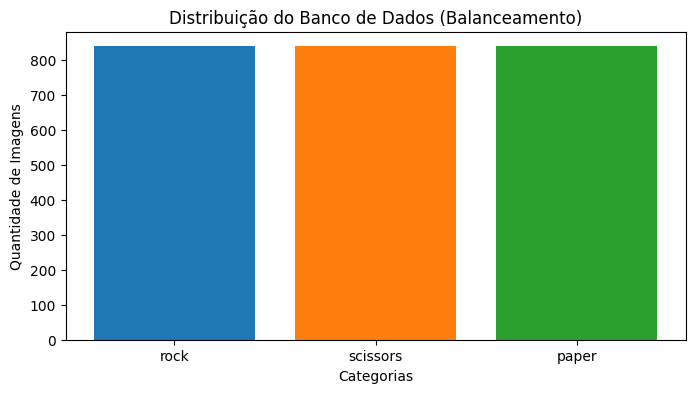

In [ ]:
# ==============================================================================
# 2. EDA: ANÁLISE DE DISTRIBUIÇÃO (BALANCEAMENTO)
# ==============================================================================
print("\n-> 2. Análise Exploratória: O Dataset possui Viés?")

contagem_classes = []
for classe in subpastas:
    quantidade = len(list((pasta_raiz / classe).glob('*.png')))
    contagem_classes.append(quantidade)
    print(f" - A classe '{classe}' possui {quantidade} imagens.")

# Gráfico de Barras para a turma visualizar o balanço
plt.figure(figsize=(8, 4))
plt.bar(subpastas, contagem_classes, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title("Distribuição do Banco de Dados (Balanceamento)")
plt.ylabel("Quantidade de Imagens")
plt.xlabel("Categorias")
plt.show()

In [ ]:
# ==============================================================================
# 3. PIPELINE DE INGESTÃO (O TRUQUE DA DIVISÃO TRIPLA)
# ==============================================================================
print("\n-> 3. Configurando Treino, Validação e TESTE...")
ALTURA_IMG, LARGURA_IMG = 150, 150
LOTE_SIZE = 32

# PASSO A: Tiramos 80% exclusivamente para o Treino
dados_treino = tf.keras.utils.image_dataset_from_directory(
  pasta_raiz,
  validation_split=0.2, # Vamos reservar 20% do total
  subset="training",    # Esta variável pega a parte majoritária (80%)
  seed=42,
  image_size=(ALTURA_IMG, LARGURA_IMG),
  batch_size=LOTE_SIZE
)

# PASSO B: Pegamos os 20% restantes (O Keras chama isso de Validation)
dados_reserva = tf.keras.utils.image_dataset_from_directory(
  pasta_raiz,
  validation_split=0.2,
  subset="validation",  # Esta variável pega os 20% reservados
  seed=42,
  image_size=(ALTURA_IMG, LARGURA_IMG),
  batch_size=LOTE_SIZE
)

nomes_oficiais = dados_treino.class_names

# PASSO C: A Mágica! Vamos fatiar os 20% da 'reserva' ao meio.
# Calculamos quantos "lotes" (batches) existem na reserva
total_lotes_reserva = tf.data.experimental.cardinality(dados_reserva).numpy()

# Dividimos pela metade (10% pro Simulado, 10% pra Prova Final)
lotes_val = total_lotes_reserva // 2

# take(): Pega a primeira metade para Validação
dados_val = dados_reserva.take(lotes_val)
# skip(): Pula a primeira metade e guarda a segunda para Teste Cego
dados_teste = dados_reserva.skip(lotes_val)

print(f"\n[DIVISÃO CONCLUÍDA]")
print(f"Lotes para Treino (80%): {tf.data.experimental.cardinality(dados_treino).numpy()}")
print(f"Lotes para Validação (10%): {tf.data.experimental.cardinality(dados_val).numpy()}")
print(f"Lotes para Teste Cego (10%): {tf.data.experimental.cardinality(dados_teste).numpy()}")

# Otimização de Leitura I/O na Memória RAM
AUTOTUNE = tf.data.AUTOTUNE
dados_treino = dados_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dados_val = dados_val.cache().prefetch(buffer_size=AUTOTUNE)
dados_teste = dados_teste.cache().prefetch(buffer_size=AUTOTUNE) # O teste também fica otimizado


-> 3. Configurando Treino, Validação e TESTE...
Found 2520 files belonging to 3 classes.
Using 2016 files for training.
Found 2520 files belonging to 3 classes.
Using 504 files for validation.

[DIVISÃO CONCLUÍDA]
Lotes para Treino (80%): 63
Lotes para Validação (10%): 8
Lotes para Teste Cego (10%): 8



-> 4. Gerando Grade Visual do Lote de Treinamento...


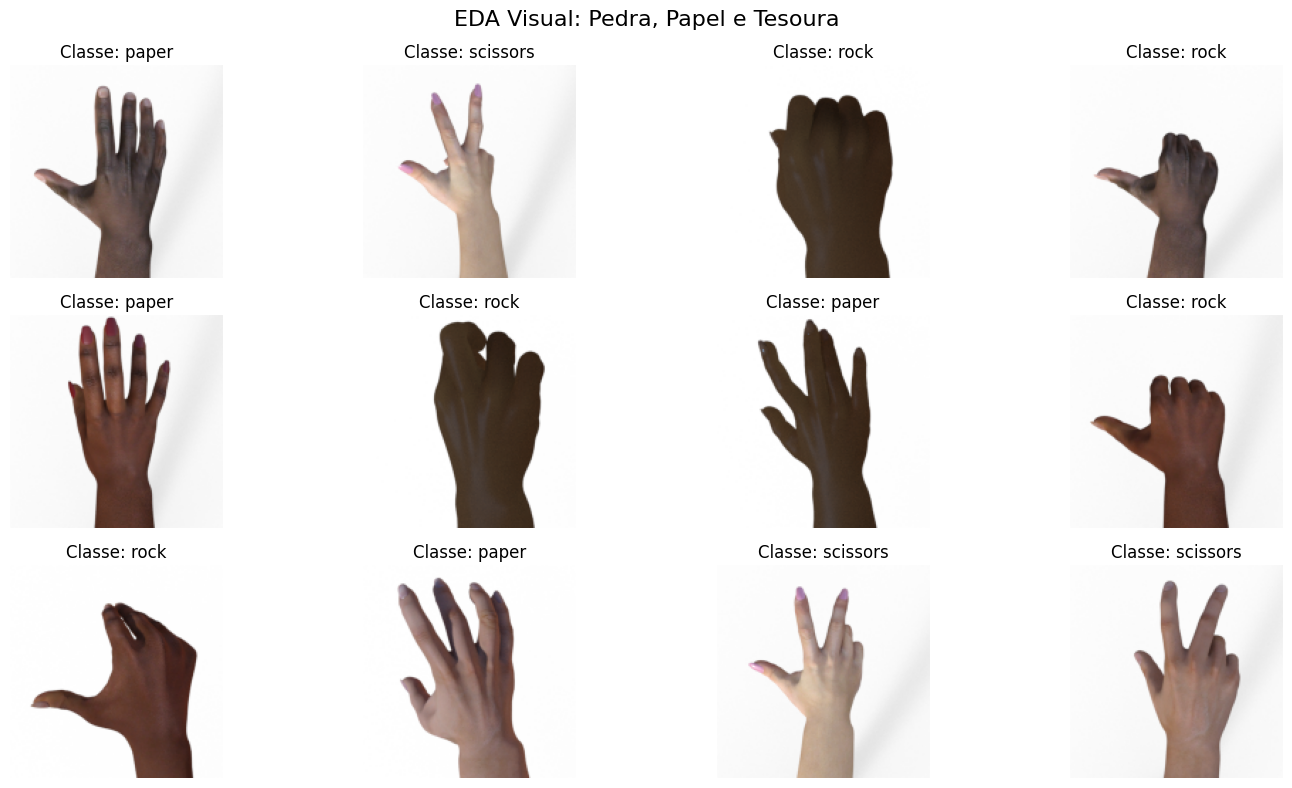

In [ ]:
# ==============================================================================
# 4. EDA VISUAL: COMO A CNN VAI ENXERGAR OS DADOS?
# ==============================================================================
print("\n-> 4. Gerando Grade Visual do Lote de Treinamento...")

plt.figure(figsize=(15, 8))
plt.suptitle("EDA Visual: Pedra, Papel e Tesoura", fontsize=16)

# Puxando apenas UM Lote (Batch) de 32 imagens
for imagens, rotulos in dados_treino.take(1):
  for i in range(12):
    ax = plt.subplot(3, 4, i + 1)

    # As imagens vêm como floats no Pipeline. Transformamos em Inteiro de 8bits (0 a 255)
    plt.imshow(imagens[i].numpy().astype("uint8"))

    nome_real = nomes_oficiais[rotulos[i]]
    plt.title(f"Classe: {nome_real}")
    plt.axis("off")

plt.tight_layout()
plt.show()